# Computing general observables
---

<font size="5"><b>Goal:</b>
Become acquainted with how to compute general observables with SAFIRE.
</font>

&nbsp;

## What you will learn
---

<font size="4">

1. What an "estimator" is and how to set one up in the json input file
2. What a mixed estimator is and when to use one to compute an observable
3. What a back-propagated estimator is and when to use one to compute an observable
4. How to compute observables in post-processing with afqmctools
</font>

&nbsp;

## Introduction
---

<font size="4">
AuxiliaryFiels uses "estimators" to compute observables.
Each estimator corresponds to a formal method for computing an observable - i.e. mixed estimators, back-propagated estimators, etc. - We will explain each of the these in the next section.
As we mentioned in the
</font>

[<font size="4">understanding the Input file tutorial</font>](../02_understanding_the_input_file/02_understanding_the_input_file.html),

<font size="4">
you can add estimators to an AFQMC calculation using an "estimator" input block.
By default, an "energy" estimator is included which is a specialized mixed estimator.
Other estimators allow you to specify one or more additional observables to compute.
</font>

&nbsp;

## Formal Background
---

Although we have not seen this explicitly, we have, so far, computed the ground state energy with AFQMC using a so-called
mixed estimator of the form

$$
\langle \hat{O} \rangle_{Mixed} = \frac{1}{\sum_k W_{n,k}} \sum_k W_{n,k} \frac{\langle \Psi_T | \hat{O} | \Phi_{n,k} \rangle }{\langle \Psi_T | \Phi_{n,k} \rangle}
$$

where $n$ is the projection step index,
$| \Phi_{n,k} \rangle$ are Slater determinant random walkers with weight $W_{n,k}$ (from importance sampling),
and $| \Psi_T \rangle$ is the trial wavefunction.
The mixed estimator provides an unbiased estimate for any observable which commutes with the Hamiltonian.
For the AFQMC energy, $\hat{O} = \hat{H}$, and trivially $[ \hat{O}, \hat{H} ] = 0$;
therefore, the mixed estimator is an unbiased choice for the total ground state energy.

On the other hand, it is often interesting to compute observables which do not commute with the Hamiltonian.
For example, the one-body reduced density matrix, from which many properties can be computed, does not commute
with the Hamiltonian.
In these cases, a back-propagated estimator is necessary to mitigate the bias that would be incurred
by using a mixed-estimator.
The back-propagated estimator has the form,
$$
\langle \hat{O} \rangle_{BP} = \frac{1}{\sum_k W_{n+m,k}} \sum_k W_{n+m,k} \frac{\langle \tilde{\Phi}_{m,k} | \hat{O} | \Phi_{n,k} \rangle }{\langle \tilde{\Phi}_{m,k} |\Phi_{n,k}\rangle}
$$

where $| \Phi_{n,k} \rangle$ are the usual forward-projected Slater determinant random walkers,
and $| \tilde{\Phi}_{m,k} \rangle$ are the back-propgated walkers given by,
$$
| \tilde{\Phi}_{m,k} \rangle = \hat{B}^\dagger( (x - \bar{x})_{n,k} ) ... \hat{B}^\dagger( (x - \bar{x})_{n+m-1,k} ) | \Psi_T \rangle
$$.
The index $n$ corresponds to the current forward projection step,
and $m$ is the back-propagated step index.
We note that each random walker has a corresponding back-propagated partner
which share the same path in auxiliary-field space.
It is important to note that the two Slater determinants are
distinct from each other since the propagator $B(x - \bar{x})$ is applied differently to each.
i.e. the propagator is applied to different Slater determinants when moving in the forward-, and backward-directions.


### ▶️ Run the cell below to setup the tutorial
-----------------------------------------------

In [1]:
# Run me (shift+enter or click the play button) to setup the tutorial!
from pathlib import Path

# simple setup
from tutorial_utils import run_afqmc, get_scratch_dir

#TODO: update this to a good directory for scratch files
home = Path.home() / ".scratch"
scratch_dir = get_scratch_dir("observables_mols", home)

&nbsp;

## Setup the Test System
---

In this tutorial, we will use PySCF for convenience; however, you can use the knowledge that you've gained in the previous tutorials to use a different quantum chemistry code if desired.

Instead of the minimal basis Hydrogen dimer, we will use the nitrogen dimer at its equilibrium bond length.
We will be using the set of canonical RHF orbitals as the orthonormal basis for AFQMC.

The code block below will:

*   setup and run RHF using PySCF
*   generate and save the RHF Slater determinant to the SAFIRE HDF5 format
*   generate and save the Hamiltonian to the SAFIRE HDF5 format

These were all covered in previous tutoirals.


<div>
<img src="https://users.flatironinstitute.org/~beskridge/tutorial_figs/6784ee4ea455921958ac327234b91ab07702736ab22fa2df804e8dccbc36a404/01_hello_auxiliary_fields/NitrogenDimer.png" width="300">
</div>

### ▶️ Run the code block below to perform all of the steps above
-----------------------------------------------------------------

In [2]:
from pathlib import Path

import h5py as h5
import numpy as np
from pyscf import gto,scf,mcscf

from afqmctools.utils.pyscf_utils import load_from_pyscf_chk_mol
from afqmctools.hamiltonian.mol import write_hamil_mol
from afqmctools.inputs.from_hdf import write_json
from afqmctools.hamiltonian.io import write_to_hdf5

from stats.scalar_dat import analyze_scalar_data

# Here, we'll generate the mol object

delta = 2.3 #2.118 # 3.0 # Bohr

atom = f'''
N 0. 0. {delta/2}
N 0. 0. -{delta/2}
'''
mol = gto.M(
    atom = atom,
    basis = '631g',
    unit = 'Bohr',
    verbose = 5,
)

rhf_chkfile = 'rhf_chkfile.h5'

rhf = scf.RHF(mol)
rhf.chkfile = scratch_dir / rhf_chkfile
rhf.run()


import numpy as np
from afqmctools.wavefunction.mol import write_wfn

number_of_electrons = mol.nelec
number_of_orbitals = mol.nao_nr()

print("Number of orbitals = ", number_of_orbitals)

orbitals = np.eye(number_of_orbitals)

phi_0 = np.array([
    orbitals[:, :number_of_electrons[0]]
])
C_0 = 1.0

wfn = ( np.array([C_0]), phi_0)

write_wfn(
    filename=scratch_dir/ "afqmc.h5",
    wfn=wfn,
    walker_type="rhf",
    nelec=number_of_electrons,
    norb=number_of_orbitals
)


# Save the Hamiltonian
basis_scf_data = load_from_pyscf_chk_mol(
    chkfile = scratch_dir / rhf_chkfile,
)

# write Hamiltonian
write_hamil_mol(
    basis_scf_data,
    hamil_file = scratch_dir / 'afqmc.h5',
    chol_cut = 1e-5,
    verbose=True
)



System: uname_result(system='Linux', node='worker6144', release='6.1.134.1.fi', version='#1 SMP Thu Apr 24 11:49:26 EDT 2025', machine='x86_64')  Threads 64
Python 3.13.2 (main, Jun 10 2025, 19:12:13) [GCC 13.3.0]
numpy 2.3.5  scipy 1.17.0  h5py 3.15.1
Date: Thu Feb  5 13:53:46 2026
PySCF version 2.12.0
PySCF path  /mnt/home/beskridge/software/SAFIRE_dev/build/safire_dev/lib/python3.13/site-packages/pyscf

[CONFIG] conf_file None
[INPUT] verbose = 5
[INPUT] max_memory = 4000 
[INPUT] num. atoms = 2
[INPUT] num. electrons = 14
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry False subgroup None
[INPUT] Mole.unit = Bohr
[INPUT] Symbol           X                Y                Z      unit          X                Y                Z       unit  Magmom
[INPUT]  1 N      0.000000000000   0.000000000000   0.608553792558 AA    0.000000000000   0.000000000000   1.150000000000 Bohr   0.0
[INPUT]  2 N      0.000000000000   0.000000000000  -0.608553792558 AA    0.0

number of shells = 10


number of NR pGTOs = 44


number of NR cGTOs = 18


basis = 631g


...

converged SCF energy = -108.826606537183


Number of orbitals =  18
 # Transforming hcore and eri to MO basis.
 # Number of basis functions: 18.
 # Performing modified Cholesky decomposition on ERI tensor.
 # Generating Cholesky decomposition of ERIs.
 # max number of cholesky vectors = 180
        iteration      max_residual              time
                0  4.1582215497e+00  2.0492076874e-03
                1  4.1127607886e+00  1.8978118896e-04
                2  5.9502116017e-01  2.1028518677e-04
                3  5.3233305052e-01  2.1147727966e-04
                4  2.0189668395e-01  1.6260147095e-04
                5  2.0189668395e-01  1.6689300537e-04
                6  1.9849299365e-01  1.6188621521e-04
                7  1.9849299365e-01  1.5330314636e-04
                8  1.9114880210e-01  1.6283988953e-04
                9  1.8986253300e-01  1.7857551575e-04
               10  1.8916390699e-01  1.7929077148e-04
               11  1.7646006132e-01  1.5878677368e-04
               12  1.3819679645e-01  1.8239021301

               46  2.1550032846e-03  9.4127655029e-04


               47  2.1088387827e-03  3.5762786865e-04
               48  2.0472950336e-03  1.7237663269e-04
               49  1.5140213815e-03  1.6283988953e-04
               50  1.3892636616e-03  1.5687942505e-04
               51  1.0375124310e-03  1.8072128296e-04
               52  9.6050413589e-04  1.5878677368e-04
               53  8.8353896764e-04  1.5687942505e-04
               54  8.6941863426e-04  1.5544891357e-04
               55  8.5258456283e-04  1.5139579773e-04
               56  8.5258456283e-04  1.4781951904e-04
               57  8.0784441095e-04  1.5830993652e-04
               58  8.0784441095e-04  1.5735626221e-04
               59  7.9355696013e-04  1.5687942505e-04
               60  7.7302560175e-04  1.6307830811e-04
               61  7.7302560175e-04  1.5711784363e-04
               62  7.1540292576e-04  1.6546249390e-04
               63  7.1540292576e-04  1.6212463379e-04
               64  6.8047285407e-04  1.4829635620e-04
               65  4.157718

               68  1.3255881844e-04  6.7567825317e-04
               69  1.2628619753e-04  1.7929077148e-04
               70  1.1945561448e-04  1.8668174744e-04
               71  9.0297957538e-05  1.5616416931e-04
               72  6.1381682449e-05  1.8715858459e-04
               73  6.1381682449e-05  1.8620491028e-04
               74  4.9983209790e-05  1.6975402832e-04
               75  4.8330492204e-05  1.6379356384e-04
               76  4.3911221473e-05  1.5068054199e-04
               77  4.3904713687e-05  1.5568733215e-04
               78  3.9823369750e-05  1.7285346985e-04
               79  3.6398003135e-05  1.6212463379e-04
               80  3.6398003135e-05  1.6355514526e-04
               81  3.4167672834e-05  1.5711784363e-04
               82  3.4167452730e-05  1.6021728516e-04
               83  3.4154372928e-05  1.5830993652e-04
               84  2.1528578987e-05  1.8024444580e-04
               85  1.8786624868e-05  1.5449523926e-04
               86  1.8588515

&nbsp;

## The "Energy" Estimator
---

By default, SAFIRE will include an "energy estimator" in the calculation.
This is formally a mixed estimator where $\hat{O} = \hat{H}$.
The Hamiltonian trivially commutes with itself, so a mixed estimator of the energy is unbiased.

You can add an energy estimator input block to your json input file in order to customize its setting.
For example, in the input block,

```json
"estimator" : {
  "name" : "energy",
  "print_components" : True,        
  "overwrite" : True
}
```

the "name" keyword tells us what kind of estimator we want.
In this case, we want an "energy" estimator.
We are setting the "print_components" and "overwrite" flags to true.
"print_components" tells SAFIRE to print the one-body, two-body coulomb, and two-body exchange contributions to the energy separately.
"overwrite" tells SAFIRE to overwrite the default energy estimator
with the one that we have defined.

&nbsp;

### Most Common Settings
---

<style>
td, th {
   border: none!important;
}
</style>
  
|<font size="4"><b>setting</b></font>|<font size="4"><b>default</b></font>|<font size="4"><b>description</b></font>|
|--:|:-:|:--|
| <font size="4"><b>        print_components</b></font> |  <font size="4">False</font> | <font size="4"> If True, print the one-body, two-body coulomb, and two-body exchange contributions to the energy in the `*.scalar.dat` file </font> |
| <font size="4"><b> equil_multiplier </b></font> | <font size="4">0</font> |  <font size="4">The multiplier that determines the length of the equilibration phase. The equilibration phase length is computed as $(equilibration\_length) = (equil\_multiplier) * (population\_control\_inveral)$ where the population control interval is defined in the execute block. During the equilibration phase, observables are not computed. </font>|
| <font size="4"><b>        overwrite</b></font> | <font size="4">False</font> |  <font size="4"> If True, overwrite the default energy estimator with the explicitly defined energy estimator </font>|

&nbsp;

### Less Common Settings

---

<style>
td, th {
   border: none!important;
}
</style>
  
|<font size="4"><b>setting</b></font>|<font size="4"><b>default</b></font>|<font size="4"><b>description</b></font>|
|--:|:-:|:--|
| <font size="4"><b>        print_sign</b></font> | <font size="4">False</font> | <font size="4"> If True, print verious quantities related to the sign/phase of random walkers in the `*.scalar.dat` file </font> |
| <font size="4"><b>        remove</b></font> |  <font size="4">False</font> |  <font size="4"> If True, remove the default energy estimator. **Note that the explicitly defined energy estimator will not be used in the calculation!** </font>|
| <font size="4"><b>        truncate</b></font> |  <font size="4">False</font> |  <font size="4"> If True, truncate the energy such that data that fall outisde of the range $[-3 var, 3 var]$, with $var$ being the variance, are set to either $-3 var$ or $3 var$, whichever is closer </font>|

&nbsp;


### ▶️ Run the code block below to write an input file
------------------------------------------------------

In [3]:
from afqmctools.inputs.from_hdf import write_json

# some shared parameters for the AFQMC run
execute_options = {
    "walker_set" : {
        "walker_type" : "COLLINEAR"
    },
    "timestep": 0.01,
    "steps": 10000,
    "population_control_interval" : 10,
    "measure_interval_multiplier": 1,
    "walker_ortho_interval" : 10 ,
    "n_walkers_per_mpi_task": 20,
    "seed" : 42,
    "estimator" : {
        "name" : "energy",
        "print_components" : True,
        "overwrite" : True
    }
}

write_json(
    scratch_dir / "afqmc.json",
    fwfn0=scratch_dir / "afqmc.h5",
    walker_type="COLLINEAR",
    exec_opts=execute_options
)

### 📝 Your Turn : Run SAFIRE with an explicit energy estimator block
---------------------------------------------------------------------

Now you can run SAFIRE, and you should see the following column headers in the `*scalar.dat` file.

```log
 block  time  nWalkers weight PseudoEloc LogOvlpFactor EnergyEstim__nume_real  EnergyEstim__nume_imag EnergyEstim__deno_real  EnergyEstim__deno_imag EnergyEstim__timer OneBodyEnergyEstim__nume_real EXXEnergyEstim__nume_real ECoulEnergyEstim__nume_real MixedEstim_timer Eshift freeMemory
```

In [4]:
run_afqmc(
    run_dir=scratch_dir,                # directory to run SAFIRE in - output files will be there as well
    input_file="afqmc.json",
    np=64,                              # number of MPI tasks
    output_file=None
)

Running AFQMC locally with 64 mpi tasks


--------------------------------------------------------------------------
Ignoring value for oob_tcp_if_exclude on worker6144 (10.250.112.0/20: Did not find interface matching this subnet).
(You can safely ignore this message.)
--------------------------------------------------------------------------


███████╗ █████╗ ███████╗██╗██████╗ ███████╗
██╔════╝██╔══██╗██╔════╝██║██╔══██╗██╔════╝
███████╗███████║█████╗  ██║██████╔╝█████╗  
╚════██║██╔══██║██╔══╝  ██║██╔══██╗██╔══╝  
███████║██║  ██║██║     ██║██║  ██║███████╗
╚══════╝╚═╝  ╚═╝╚═╝     ╚═╝╚═╝  ╚═╝╚══════╝


AF App version: 1.0.0
This build has the following enabled:
 - MKL:  1
 - CUDA: 0
 - HIP:  0
app git branch: develop
app git commit: 37f8dfbd4713f6c1dc37eb0880f08ed3a64a8a53-dirty
app git commit date: Mon Jan 26 13:59:12 2026 -0500
 AFQMCFactory Project settings: 
    -- mixed_precision: false 
    -- ncores (local) : 1 
    -- n_groups       : 1 
    -- id             : qmc 
    -- series         : 0 
    -- MPI tasks/node : 64 
    -- MPI nodes      : 1 
    -- MPI tasks      : 64 



DrvFac::executeAFQMCNewDriver input:
wavefunction: 
  filename: afqmc.h5
walker_set: 
  walker_type: COLLINEAR
hdf_read_file: 
set_nwalker_to_target: false
n_walkers_per_mpi_task: 20
timestep: 0.01
seed: 42
initial_Eshift: 0



**************

 getHamOps from scratch
reading real-valued 1-body Hamiltonian
Upgrading Closed 1-body integrals to Collinear 1-body integrals.

NOMSD input:
nbatch: 0
number_of_references: -1
rediag: false



****************************************************
               Initializing Propagator 

****************************************************

BasePropagator input:

nbatch: 0
nbatch_qr: 0
i: -1
a: -1
vbias_bound: 50
external_field_scale: 1
upper_cutoff_scale: 10
lower_cutoff_scale: 1
apply_constrain: true
importance_sampling: true
substractMF: true
hybrid: true
printP1eigval: false
free_projection: false
denseP1: false
external_field: 
excited: 
debug_verbosity: false




 --------------- Constructing Propagator ------------------ 

 Using sequential propagation. 
 vbias_bound: 50
 Using sparse 1-body propagator
 Using hybrid method to calculate the weights during the propagation.
 Local Energy of starting determinant 
  - Total energy    : (-108.826599, 0.000000)
  - One-body energy : (-1

***************************************************************************
                    Timer Name:     Elapsed (s)    Averaged (s)  # calls
***************************************************************************
    WalkerSetBase::loadBalance:     0.014614365   1.3407674e-05     1090
      WalkerSetBase::branching:       7.7071045    0.0070707381     1090
                         Block:         1140366        114.0366    10000
                  PseudoEnergy:       13.843819    0.0013843819    10000
                        Energy:               0               0        0
                           vHS:       1.1780434   0.00011780434    10000
                             X:       19.081329    0.0019081329    10000
                         vbias:       1.0876578   0.00010876578    10000
                   G_for_vbias:       32.810754    0.0032810754    10000
                     Propagate:       103.06008     0.010306008    10000
                MixedEstimator:              

AFQMC ran in 236.985049 seconds


236.98504928298644

You can check the `*.scalar.dat` file to verify that the extra columns that we requested were printed.

In [5]:
!head -n 10 $scratch_dir/qmc.s000.scalar.dat

# block  time  nWalkers weight PseudoEloc LogOvlpFactor EnergyEstim__nume_real  EnergyEstim__nume_imag EnergyEstim__deno_real  EnergyEstim__deno_imag EnergyEstim__timer OneBodyEnergyEstim__nume_real EXXEnergyEstim__nume_real ECoulEnergyEstim__nume_real Eshift freeMemory 
1 0.1 1280 1318.6 -49.05107704066536 1.300409792788396 -108.886039420808 -0.000416233723191908 1 -1.119050978705571e-18 0.02693614 -167.9238276018797 -12.86608646723074 71.90387464830241 -58.2710332005  1001994 
2 0.2 1280 1279.98 -58.22610512917383 1.212409016124845 -108.9315870458265 -0.0006496755220355688 0.9999999999999998 1.743671205222341e-18 0.026523877 -167.9291368051364 -12.84498433521301 71.84253409452292 -58.2570940805  1001986 
3 0.3 1280 1279.99 -58.26020434469954 1.149465171324901 -108.9686471972927 0.0006836686036057544 0.9999999999999998 -1.552543621989533e-18 0.026364522 -167.9340957107114 -12.82825406273544 71.79370257615422 -58.2883717912  1001979 
4 0.4 1280 1279.93 -58.29678982422107 1.098093056180

&nbsp;

## Extracting and Analyzing the AFQMC energy.
---

We learned about basic energy analysis using the CLI and the `analyze_scalar_data()` Python function in the Hello SAFIRE tutorial.
We can use the same tools here to get the average AFQMC energy and the stochastic uncertainty.

For pedagogical reasons, we will instead read the entire scalar data file so that we can plot several of the data columns as a function of total projection time.
In the code block below, the total energy (solid blue line) is plotted against as well as the sum of the three individual columns (dotted orange line) corresponding to the one-body energy, the Coulomb energy, and the exchange energy.
The two curves agree with each other to machine precision.

### ▶️ Run the code block below to extract and plot energy samples
------------------------------------------------------------------

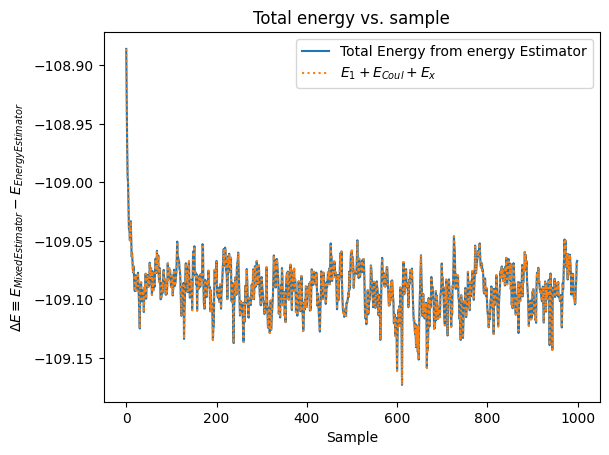

In [6]:
from types import SimpleNamespace
from stats.scalar_dat import analyze_scalar_data,read_scalar_table

# read scalar table and return as a pandas DataFrame
args = SimpleNamespace(
    fname=scratch_dir / "qmc.s000.scalar.dat",
    append=None,
    mark_header="#"
)
df = read_scalar_table(args)


# read the energy components
one_body_energy = df["OneBodyEnergyEstim__nume_real"].values
direct_coulomb_energy = df["ECoulEnergyEstim__nume_real"].values
exchange_energy = df["EXXEnergyEstim__nume_real"].values

two_body_energy = direct_coulomb_energy + exchange_energy

# read the total energy
total_energy = df["EnergyEstim__nume_real"].values

# plot the energy both ways
import matplotlib.pyplot as plt

plt.plot(total_energy,label="Total Energy from energy Estimator")
plt.plot(one_body_energy + direct_coulomb_energy + exchange_energy, ":", label=r"$E_1 + E_{Coul} + E_{x}$")

plt.legend()
plt.xlabel("Sample")
plt.ylabel(r"$\Delta E \equiv E_{MixedEstimator} - E_{EnergyEstimator}$")
plt.title(r"Total energy vs. sample")

plt.show()

&nbsp;

## Computing Observables using a "Mixed" Estimator
---

SAFIRE also includes a mixed estimator that periodically evaluates,

$$
\langle \hat{O} ⟩_{Mixed} = \frac{1}{\sum_k W_{n,k}} \sum_k W_{n,k} \frac{\langle \Psi_T | \hat{O} | \Phi_{n,k} \rangle }{\langle \Psi_T | \Phi_{n,k} \rangle},
$$
where $\hat{O}$ is an operator.
The one-body reduced density matrix (1rdm), given by

$$\hat{O} = \hat{\rho}^1 = \sum_{ij}\sum_{\sigma \sigma'} \hat{c}^\dagger_{i \sigma}\hat{c}_{j \sigma'},$$

and the two-body reduced density matrix (2rdm), given by,

$$\hat{O} = \hat{\rho}^2 = \sum_{ijkl}\sum_{\sigma \sigma'}\hat{c}^\dagger_{i\sigma}\hat{c}^\dagger_{j\sigma'}\hat{c}_{k\sigma'}\hat{c}_{l\sigma}$$

are common observables.


<div class="alert alert-block alert-info">
<b>Note:</b>
    computing the 2rdm is very time and memory intensive; this shuld only be done for small systems.
</div>

### Specifying Observables to Measure
---------------------------------------

You can specify which observables you want to compute by
adding a corresponding observable block to an estimator
block.
For example, the estimator block below includes both the 1rdm, and the 2rdm.

```json
"estimator" : {
    "name" : "mixed",
    "onerdm" : {
        "name" : "my_onerdm"
    },
    "twordm" : {
        "name" : "my_twordm"
    }
}
```

As we will see later, this is exactly how observables are specified for the BP estimator as well.
See the [User Manual](https://users.flatironinstitute.org/~beskridge/safire/user_manual/observables.html#observables) for a complete list of currently implemented observables.

### Pedagogical Demonstration
-----------------------------

Below, we will use a mixed estimator to compute the 1-rdm, and the 2-rdm.
We can then directly compute each contribution to the AFQMC energy,

$$E_{one-body} = \sum_{ij} H^1_{ij} \rho^1_{ji} $$

$$E_{two-body} = \sum_{ijkl} H^2_{ijkl} \rho^2_{ijkl} $$

and compare with the results from the energy estimator.
**We should find exact agreement between the two if we use the same AFQMC run parameters.**

We note that computing the 2rdm is very memory intensive since many samples of the 2rdm will be saved.
It is not typically computed unless absolutely necessary.


### ▶️ Run the code block below to write an input file with mixed estimator
---------------------------------------------------------------------------

In [7]:
from afqmctools.inputs.from_hdf import write_json

# some shared parameters for the AFQMC run
execute_options = {
    "walker_set" : {
        "walker_type" : "COLLINEAR"
    },
    "timestep": 0.01,
    "steps": 10000,
    "measure_interval_multiplier": 1,
    "population_control_interval" : 10,
    "walker_ortho_interval" : 10 ,
    "n_walkers_per_mpi_task": 20,
    "seed" : 42,
    "estimator" : {
        "name" : "energy",
        "print_components" : True,
        "overwrite" : True
    },
    "estimator" : {
        "name" : "mixed",
        "onerdm" : {
            "name" : "my_onerdm"
        },
        "twordm" : {
            "name" : "my_twordm"
        }
    }
}

write_json(
    scratch_dir / "afqmc_1.json",
    fwfn0=scratch_dir / "afqmc.h5",
    exec_opts=execute_options,
    series=1
)

Now, we can run AFQMC with a Mixed Estimator in order to compute the 1-rdm.
**This will probably take a while!** To finish the tutorial more quickly, remove the "twordm" block from the input and just compate the one-body energy.

In [8]:
run_afqmc(
    run_dir=scratch_dir,                # directory to run SAFIRE in - output files will be there as well
    input_file="afqmc_1.json",
    np=64,                              # number of MPI tasks
    output_file=None
)

Running AFQMC locally with 64 mpi tasks
--------------------------------------------------------------------------
Ignoring value for oob_tcp_if_exclude on worker6144 (10.250.112.0/20: Did not find interface matching this subnet).
(You can safely ignore this message.)
--------------------------------------------------------------------------


███████╗ █████╗ ███████╗██╗██████╗ ███████╗
██╔════╝██╔══██╗██╔════╝██║██╔══██╗██╔════╝
███████╗███████║█████╗  ██║██████╔╝█████╗  
╚════██║██╔══██║██╔══╝  ██║██╔══██╗██╔══╝  
███████║██║  ██║██║     ██║██║  ██║███████╗
╚══════╝╚═╝  ╚═╝╚═╝     ╚═╝╚═╝  ╚═╝╚══════╝


AF App version: 1.0.0
This build has the following enabled:
 - MKL:  1
 - CUDA: 0
 - HIP:  0
app git branch: develop
app git commit: 37f8dfbd4713f6c1dc37eb0880f08ed3a64a8a53-dirty
app git commit date: Mon Jan 26 13:59:12 2026 -0500
 AFQMCFactory Project settings: 
    -- mixed_precision: false 
    -- ncores (local) : 1 
    -- n_groups       : 1 
    -- id             : qmc 
    -- series         : 1 
    -- MPI tasks/node : 64 
    -- MPI nodes      : 1 
    -- MPI tasks      : 64 



DrvFac::executeAFQMCNewDriver input:
wavefunction: 
  filename: afqmc.h5
walker_set: 
  walker_type: COLLINEAR
hdf_read_file: 
set_nwalker_to_target: false
n_walkers_per_mpi_task: 20
timestep: 0.01
seed: 42
initial_Eshift: 0



**************

 getHamOps from scratch
reading real-valued 1-body Hamiltonian
Upgrading Closed 1-body integrals to Collinear 1-body integrals.

NOMSD input:
nbatch: 0
number_of_references: -1
rediag: false



****************************************************
               Initializing Propagator 

****************************************************

BasePropagator input:

nbatch: 0
nbatch_qr: 0
i: -1
a: -1
vbias_bound: 50
external_field_scale: 1
upper_cutoff_scale: 10
lower_cutoff_scale: 1
apply_constrain: true
importance_sampling: true
substractMF: true
hybrid: true
printP1eigval: false
free_projection: false
denseP1: false
external_field: 
excited: 
debug_verbosity: false




 --------------- Constructing Propagator ------------------ 

 Using sequential propagation. 
 vbias_bound: 50
 Using sparse 1-body propagator
 Using hybrid method to calculate the weights during the propagation.
 Local Energy of starting determinant 
  - Total energy    : (-108.826599, 0.000000)
  - One-body energy : (-1

***************************************************************************
                    Timer Name:     Elapsed (s)    Averaged (s)  # calls
***************************************************************************
    WalkerSetBase::loadBalance:     0.012737484   1.1685765e-05     1090
      WalkerSetBase::branching:       7.7315565    0.0070931711     1090
                         Block:       1800700.4       180.07004    10000
                  PseudoEnergy:       14.142816    0.0014142816    10000
                        Energy:               0               0        0
                           vHS:       1.1500961   0.00011500961    10000
                             X:        19.34085     0.001934085    10000
                         vbias:       1.0178782   0.00010178782    10000
                   G_for_vbias:       32.982098    0.0032982098    10000
                     Propagate:       103.62839     0.010362839    10000
                MixedEstimator:       93.3662

AFQMC ran in 365.893165 seconds


365.89316467999015

### Data Extraction and Analysis
---

afqmctools provides several tools for extracting data - i.e. retrieving data from the SAFIRE output files - and analyzing data - ariving at a final average with stochastic uncertainty.

Since some observables require a large amount of memory to store, `afqmctools` also provides "transforms" which are applied to the raw observables as they are read from disk.
For example, in the cell below, a enery evaluation transform is used to compute the one-body energy, a scalar, on the fly as one-rdm samples are read from the *.h5 data file.
This dramatically reduces the memory needed to analyze the AFQMC results from SAFIRE.

### ▶️ Run the code below to evlaute the one-body energy from the one-rdm, and compare with the energy estimator
----------------------------------------------------------------------------------------------------------------

/mnt/home/beskridge/software/SAFIRE_dev/utils/afqmctools/analysis/transform.py:248: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(complex128, 2, 'A', False, aligned=True), Array(complex128, 1, 'C', False, aligned=True))
  spin_up_contribution = data[:,0] @ one_body_operator.flatten()


/mnt/home/beskridge/software/SAFIRE_dev/build/safire_dev/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/mnt/home/beskridge/software/SAFIRE_dev/build/safire_dev/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


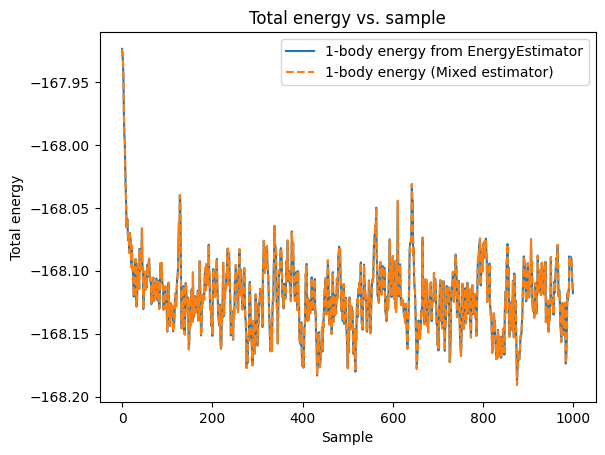

In [9]:
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np

from afqmctools.hamiltonian.converter import read_hamiltonian
from afqmctools.analysis.extraction import extract_observable,get_metadata
from afqmctools.analysis.transform import hermitize_factory,eval_one_body_obs_factory,eval_two_body_obs_factory

from afqmctools.analysis.average import WALKER_TYPE

# read the Hamiltonian
H = read_hamiltonian(scratch_dir / "afqmc.h5")
M = H["nmo"]
Econst = H["enuc"]

walker_type = WALKER_TYPE[get_metadata(scratch_dir/"qmc.s001.stat.h5")["WalkerType"]]

# set up a transform to compute the one-body energy from the one-rdm
eval_one_body_energy = eval_one_body_obs_factory(
    one_body_operator=H["hcore"],
    walker_type=walker_type
)
# set up a transform the hermitize the one-rdm
hermitize = hermitize_factory(
    walker_type=walker_type
)


# Extract and Transform data
Energy_1body = extract_observable(
    scratch_dir/"qmc.s001.stat.h5",    # filename
    estimator='mixed',
    name="one_rdm",                    # observable type
    ix=0,                              # index of the "average" - we'll return to this below!
    transform=[hermitize,eval_one_body_energy],  # list of transforms to apply *FROM LEFT TO RIGHT*
)
# add in constant energy for consistency with AuxilaryFields convention
Energy_1body += Econst


plt.plot(one_body_energy,label="1-body energy from EnergyEstimator")
plt.plot(Energy_1body,'--',label="1-body energy (Mixed estimator)")
plt.legend()
plt.xlabel("Sample")
plt.ylabel("Total energy")
plt.title("Total energy vs. sample")
plt.show()

### ▶️ Run the code block below to plot the difference between the mixed, and energy estimator
----------------------------------------------------------------------------------------------

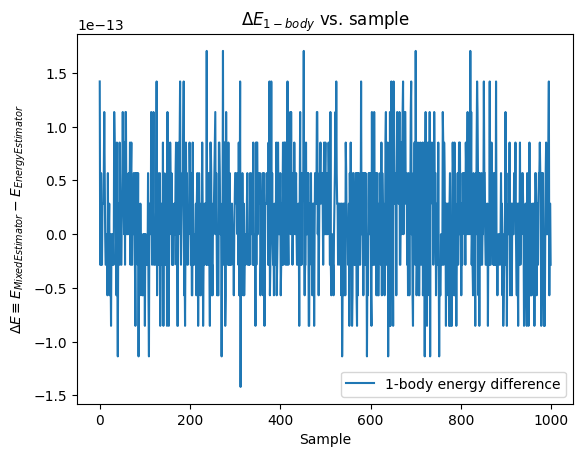

In [10]:
# now, look at the difference!
delta_E = Energy_1body[:,0] - one_body_energy

# plot the difference between the two energies
plt.plot(delta_E,label="1-body energy difference")
plt.legend()
plt.xlabel("Sample")
plt.ylabel(r"$\Delta E \equiv E_{MixedEstimator} - E_{EnergyEstimator}$")
plt.title(r"$\Delta E_{1-body}$ vs. sample")

plt.show()

As we can see, the energy computed using the one-body reduced density matrix with a mixed estimator yeilds the exact same one-body energies as the energy estimator to very high precision.
This is no surprise since the energy estimator is simply a specialized mixed estimator.


### 📝 Your Turn : Extract the 2rdm and compute the 2-body energy
-----------------------------------------------------------------

Note: You can skip this section if you chose to not compute the "twordm"
obserable above.

Repeat the same excercise for the two-body energy.
As we saw in the energy estimator section, the exchange and direct coulomb energies are printed to file separately by the energy estimator.

To compute the two-body energy, you will need to measure the "twordm" observable during AFQMC, and extract and transform it.

We provide code for setting up the appropriate transform functions in the code block below.


/mnt/home/beskridge/software/SAFIRE_dev/utils/afqmctools/analysis/transform.py:298: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(complex128, 2, 'A', False, aligned=True), Array(complex128, 1, 'C', True, aligned=True))
  O2_aaaa = np.dot(data[:,0], two_body_operator)


/mnt/home/beskridge/software/SAFIRE_dev/utils/afqmctools/analysis/transform.py:294: NumbaWarning: Cannot cache compiled function "transform" as it uses dynamic globals (such as ctypes pointers and large global arrays)
  @jit(cache=True)


/mnt/home/beskridge/software/SAFIRE_dev/build/safire_dev/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/mnt/home/beskridge/software/SAFIRE_dev/build/safire_dev/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


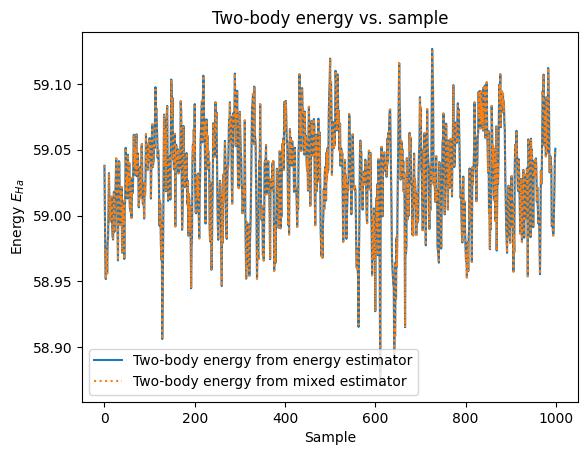

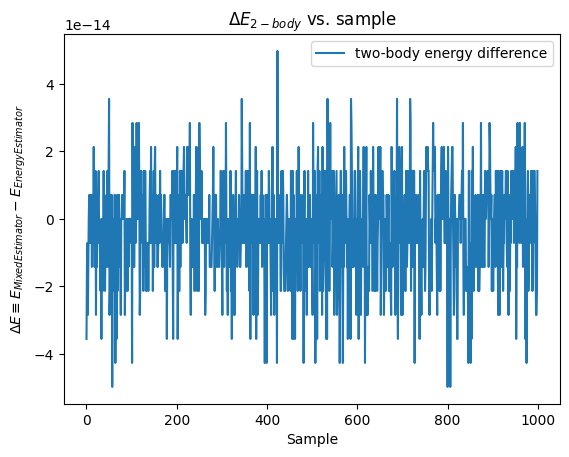

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from afqmctools.analysis.transform import hermitize_factory,eval_one_body_obs_factory,eval_two_body_obs_factory

ncv = H["chol"].shape[-1]
cholesky_vectors = np.transpose(H["chol"].reshape((M,M,ncv)),(2,0,1))
eri = np.einsum("gil,gjk->iljk",cholesky_vectors,cholesky_vectors).flatten()

eval_two_body_energy = eval_two_body_obs_factory(
    two_body_operator=eri,  # 📝 YOUR TURN: Supply the correct two-body operator
    walker_type=walker_type
)

Energy_2body_mixed = extract_observable(
    scratch_dir/"qmc.s001.stat.h5",
    estimator='mixed',
    name="two_rdm",
    ix=0,
    transform=eval_two_body_energy, # 📝 YOUR TURN: Supply the transform function to compute the two-body energy,
    batch_size=1
)

plt.plot(two_body_energy,label="Two-body energy from energy estimator")
plt.plot(Energy_2body_mixed,":",label="Two-body energy from mixed estimator")
plt.legend()
plt.xlabel("Sample")
plt.ylabel(r"Energy $E_{Ha}$")
plt.title("Two-body energy vs. sample")
plt.show()


# plot the difference as well!
delta_E = Energy_2body_mixed[:,0] - two_body_energy

# plot the difference between the two energies
plt.plot(delta_E,label="two-body energy difference")
plt.legend()
plt.xlabel("Sample")
plt.ylabel(r"$\Delta E \equiv E_{MixedEstimator} - E_{EnergyEstimator}$")
plt.title(r"$\Delta E_{2-body}$ vs. sample")

plt.show()


Once again, we see that the two body energy computed from the two-body reduced density matrix samples is the same as the two body energy from the energy estimator (after adding the exchange and direct Coulomb contributions together, of course).

## Averaging Observables
---

Averaging observables computed using AFQMC requires some care.

First, one must make sure that the data is equilibrated.

Second, in AFQMC, successive samples are not independent since they depend on the recent history of each walker.
This is known as "autocorrelation".
Care must be take to remove autocorrelation effects or the stochastic uncertainty will be underestimated.

The former can be achieved by visualizing the observable over imaginary time, and finding the equilibration time by inspection.
We saw this in the [Hello SAFIRE](../01_hello_safire/01_hello_safire.html) tutorial.
afqmctools provides tools for automatically computing the auto-correlation time - i.e. the time interval at which measurments are no longer autocorrelated - and adjusting the number of effective samples accordingly.

In the code cell below, we demonstrate how to use the provided tools to automatically compute averages.



====== [analyze_scalar_data Settings] ======

[+] fname            = /mnt/home/beskridge/.scratch/observables_mols/qmc.s000.scalar.dat
[+] mark_header      = #               
[+] series_column    = time            
[+] nequil           = 5               
[+] estimate_equil   = False           
[+] column           = LocalEnergy     
[+] reblock          = 1               
[+] list             = False           
[+] trace            = True            
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] savefig          = None            
[+] ndiscard         = None            
[+] return_data      = False           
[+] autocorr         = None            
[+] verbose          = True            
[+] dump_avail_columns = False           



AFQMC Energy   -109.091613 +/-   0.001690 8.30  5.0/100.0


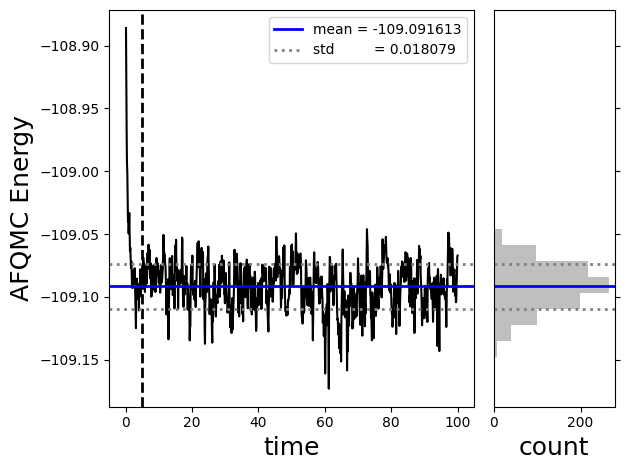

(np.float64(-109.09161298249478), np.float64(0.0016895073842018422))

In [12]:
from afqmctools.analysis.average import average_observable

E1body = average_observable(
    filename=scratch_dir/"qmc.s001.stat.h5",
    name = "one_rdm",
    eqlb=20, # EXERCISE: Set this to an appropriate value based on the energy vs projection time curve above.
    estimator='mixed',
    ix=0,
    blocksize=1,
    transform=[hermitize,eval_one_body_energy],
    remove_auto_correlation=True # you can turn this off if you prefer to remove autocorrelation yourself.
)

## compare with the analyze_scalar_stats result:
from stats.scalar_dat import analyze_scalar_data

analyze_scalar_data(dict(
    fname = scratch_dir/"qmc.s000.scalar.dat",
    series_column = "time",
    nequil = 5,
    trace = True
))

## Back-Propagation (BP) in SAFIRE
---

Mixed estimators are biased for observables $\hat{O}$ such that $[\hat{O},\hat{H}] \neq 0$, which requires the use of pure estimators. The Back-Propagation (BP) algorithm is used to compute pure estimators efficiently in SAFIRE.

### Basic BP Configuration
---

BP is invoked in SAFIRE by including a "back_propagation" estimator in the input file:

```json
{
  "estimator": {
    "name": "back_propagation",
    "path_restoration": true,
    "bp_walker_ortho_interval": 5,
    "measure_interval_multiplier": 20,
    "equil_multiplier": 100,
    "onerdm": {
      "name": "one_rdm"
    }
  }
}
```

Observables are added to the BP block in the same way as for mixed estimators.

### Measurement Intervals
---

Since BP involves an additional projection, the measurement interval controls the number of back-propagated steps.
Just as in the execute block or a mixed estimator block, the input file includes a measurement interval "multiplier", and the actual measurement interval, $m$, is determined as:

$$
m = (\textrm{measure\_interval\_multiplier}) \times (\textrm{population\_control\_interval})
$$



### Multiple BP Lengths
---

SAFIRE implements the capability of running BP with multiple BP measurement lengths.
We call each measurement with a different BP length an "average".
This allows the forward projection to be reused while checking for convergence in the BP length.
To define multiple BP lengths/averages, simply provide a JSON array for measure_interval_multiplier corresponding to all of the BP lengths that you would like to use:

```json
{
  "estimator": {
    "name": "back_propagation",
    "path_restoration": true,
    "bp_walker_ortho_interval": 10,
    "measure_interval_multiplier": [60, 70, 80],
    "equil_multiplier": 80,
    "onerdm": {
      "name": "one_rdm"
    }
  }
}
```

### Equilibration Phase
---

The BP estimator implements an equilibration phase at the beginning of the AFQMC calculation where no BP is performed.
This is recommended since computing observables is expensive and since AFQMC needs to equilibrate before samples can meaningfully contribute to the average.
Similarly to the measure_interval_multiplier, the equilibration time is specified as an equilibration multiplier (`"equil_multiplier"`) and the actual equilibration time is given by:

$$
\textrm{equil\_time} = (\textrm{equil\_multiplier}) \times (\textrm{population\_control\_interval})
$$

### All Settings
----------------

<style>
td, th {
   border: none!important;
}
</style>
  
|<font size="4"><b>setting</b></font>|<font size="4"><b>default</b></font>|<font size="4"><b>description</b></font>|
|--:|:-:|:--|
| <font size="4"><b>        measure_interval_multiplier</b></font> |  <font size="4"> 1 </font> | <font size="4"> controls the number of back propagation steps which are determined as $(\textrm{number of BP steps}) = (\textrm{measure\_interval\_multiplier}) \times (\textrm{population\_control\_interval})$. Can be either a single value or multiple values. If multiple values are provided, BP will be performed with each corresponding number of BP steps and observables are accumulated and saved for each distinct BP length. </font> |
| <font size="4"><b> equil_multiplier </b></font> | <font size="4">0</font> |  <font size="4">The multiplier that determines the length of the equilibration phase. The equilibration phase length is computed as $(\textrm{equilibration\_length}) = (\textrm{equil\_multiplier}) * (\textrm{population\_control\_inveral})$ where the population control interval is defined in the execute block. During the equilibration phase, observables are not computed. </font>|
| <font size="4"><b>        bp_walker_ortho_interval</b></font> |  <font size="4"> 1 </font> | <font size="4">  interval for performing walker orthonormalization during back-propagation (i.e. for the left-hand side Walkers) </font> |
| <font size="4"><b>        path_restoration</b></font> |  <font size="4"> false </font> | <font size="4"> If true, perform path restoration. </font> |
| <font size="4"><b>        extra_path_restoration</b></font> |  <font size="4"> false </font> | <font size="4">  If true, perform an extra path restoration. </font> |


### Demonstraiton of BP
-----------------------

For the sake of execution time, we will compute only the one-rdm using the back-propagation estimator.
We will find that the one-body energy computed using the BP one-rdm will *not* agree with the one computed using a mixed estimator.
The BP-estimated one-body energy is unbiased, and represents a better estimate of the one-body energy than that provided by the mixed estimator.

### ▶️ Run the code block below to write an input file with a BP Estimator
--------------------------------------------------------------------------

In [13]:
# Example: Setting up a BP calculation with multiple BP lengths
from afqmctools.inputs.from_hdf import write_json

# Create a scratch directory for BP calculations
scratch_dir_bp = get_scratch_dir("observables_mols_bp", home)

# Copy the Hamiltonian and wavefunction files
import shutil
shutil.copy(scratch_dir / "afqmc.h5", scratch_dir_bp / "afqmc.h5")

# Set up AFQMC parameters with back-propagation
execute_options_bp = {
    "walker_set": {
        "walker_type": "COLLINEAR"
    },
    "timestep": 0.005,
    "steps": 20000,
    "measure_interval_multiplier": 2,
    "population_control_interval": 5,
    "walker_ortho_interval": 10,
    "n_walkers_per_mpi_task": 20,
    "seed": 42,
    "estimator": {
        "name": "back_propagation",
        "path_restoration": True,
        "bp_walker_ortho_interval": 5,
        "measure_interval_multiplier": [1, 2, 3],  # Multiple BP lengths
        "equil_multiplier": 30,  # Equilibration phase
        "onerdm": {
            "name": "one_rdm"
        }
    }
}

write_json(
    scratch_dir_bp / "afqmc_bp.json",
    fwfn0=scratch_dir_bp / "afqmc.h5",
    walker_type="COLLINEAR",
    exec_opts=execute_options_bp,
    series=2
)

print("Back-propagation input file created with the following BP parameters:")
print(f"- Multiple BP lengths: {execute_options_bp['estimator']['measure_interval_multiplier']}")
print(f"- Equilibration multiplier: {execute_options_bp['estimator']['equil_multiplier']}")
print(f"- Population control interval: {execute_options_bp['population_control_interval']}")
print(f"- Actual BP lengths: {[m * execute_options_bp['population_control_interval'] for m in execute_options_bp['estimator']['measure_interval_multiplier']]}")
print(f"- Equilibration time: {execute_options_bp['estimator']['equil_multiplier'] * execute_options_bp['population_control_interval']}")

Back-propagation input file created with the following BP parameters:
- Multiple BP lengths: [1, 2, 3]
- Equilibration multiplier: 30
- Population control interval: 5
- Actual BP lengths: [5, 10, 15]
- Equilibration time: 150


### ▶️ Run SAFIRE with BP
-------------------------

In [14]:
# Run AFQMC with back-propagation
print("Running AFQMC with back-propagation estimator...")
print("This will take longer than mixed estimators due to the additional back-propagation steps.")

run_afqmc(
    run_dir=scratch_dir_bp,
    input_file="afqmc_bp.json",
    np=64,
    output_file=None
)

Running AFQMC with back-propagation estimator...
This will take longer than mixed estimators due to the additional back-propagation steps.
Running AFQMC locally with 64 mpi tasks
--------------------------------------------------------------------------
Ignoring value for oob_tcp_if_exclude on worker6144 (10.250.112.0/20: Did not find interface matching this subnet).
(You can safely ignore this message.)
--------------------------------------------------------------------------


███████╗ █████╗ ███████╗██╗██████╗ ███████╗
██╔════╝██╔══██╗██╔════╝██║██╔══██╗██╔════╝
███████╗███████║█████╗  ██║██████╔╝█████╗  
╚════██║██╔══██║██╔══╝  ██║██╔══██╗██╔══╝  
███████║██║  ██║██║     ██║██║  ██║███████╗
╚══════╝╚═╝  ╚═╝╚═╝     ╚═╝╚═╝  ╚═╝╚══════╝


AF App version: 1.0.0
This build has the following enabled:
 - MKL:  1
 - CUDA: 0
 - HIP:  0
app git branch: develop
app git commit: 37f8dfbd4713f6c1dc37eb0880f08ed3a64a8a53-dirty
app git commit date: Mon Jan 26 13:59:12 2026 -0500
 AFQMCFactory Project settings: 
    -- mixed_precision: false 
    -- ncores (local) : 1 
    -- n_groups       : 1 
    -- id             : qmc 
    -- series         : 2 
    -- MPI tasks/node : 64 
    -- MPI nodes      : 1 
    -- MPI tasks      : 64 



DrvFac::executeAFQMCNewDriver input:
wavefunction: 
  filename: afqmc.h5
walker_set: 
  walker_type: COLLINEAR
hdf_read_file: 
set_nwalker_to_target: false
n_walkers_per_mpi_task: 20
timestep: 0.0050000000000000001
seed: 42
initial_Eshift: 0


 getHamOps from scratch
reading real-valued 1-body Hamiltonian
Upgrading Closed 1-body integrals to Collinear 1-body integrals.

NOMSD input:
nbatch: 0
number_of_references: -1
rediag: false



****************************************************
               Initializing Propagator 

****************************************************

BasePropagator input:

nbatch: 0
nbatch_qr: 0
i: -1
a: -1
vbias_bound: 50
external_field_scale: 1
upper_cutoff_scale: 10
lower_cutoff_scale: 1
apply_constrain: true
importance_sampling: true
substractMF: true
hybrid: true
printP1eigval: false
free_projection: false
denseP1: false
external_field: 
excited: 
debug_verbosity: false




 --------------- Constructing Propagator ------------------ 

 Using sequential propagation. 
 vbias_bound: 50
 Using sparse 1-body propagator
 Using hybrid method to calculate the weights during the propagation.
 Local Energy of starting determinant 
  - Total energy    : (-108.826599, 0.000000)
  - One-body energy : (-1

***************************************************************************
                    Timer Name:     Elapsed (s)    Averaged (s)  # calls
***************************************************************************
    WalkerSetBase::loadBalance:     0.039582898   9.5151197e-06     4160
      WalkerSetBase::branching:        29.37343    0.0070609207     4160
                         Block:         9350180         467.509    20000
                  PseudoEnergy:       27.249925    0.0013624962    20000
                        Energy:               0               0        0
                           vHS:       2.2233455   0.00011116728    20000
                             X:       40.361325    0.0020180663    20000
                         vbias:       2.0955816   0.00010477908    20000
                   G_for_vbias:       66.494881     0.003324744    20000
                     Propagate:       206.71993     0.010335996    20000
                MixedEstimator:              

AFQMC ran in 944.028929 seconds


944.0289291210065

### ▶️ Run the code below to evlaute the one-body energy from the one-rdm, and compare with the BP estimator
------------------------------------------------------------------------------------------------------------

In [15]:
# Extract and analyze BP results
from afqmctools.analysis.extraction import extract_observable, get_metadata
from afqmctools.analysis.average import WALKER_TYPE
from afqmctools.analysis.transform import hermitize_factory

# Check the metadata to understand the walker type
metadata = get_metadata(scratch_dir_bp / "qmc.s002.stat.h5")
bp_metadata = get_metadata(scratch_dir_bp / "qmc.s002.stat.h5", path="/Observables/BackPropagated/")

walker_type = WALKER_TYPE[metadata["WalkerType"]]
print(f"Walker type: {walker_type}")

# set up a transform the hermitize the one-rdm
hermitize = hermitize_factory(
    walker_type=walker_type
)

# Extract one-RDM data from all BP averages
print("\nExtracting one-RDM data from back-propagation averages...")

# We specified 3 BP lengths: [60, 70, 80] * population_control_interval
bp_lengths = bp_metadata["BackPropSteps"]
bp_onerdm_data = {}

for iav, bp_length in enumerate(bp_lengths):
    print(f"Extracting average {iav} (BP length = {bp_length} * {execute_options_bp['population_control_interval']} = {bp_length * execute_options_bp['population_control_interval']} steps)")

    # Extract the one-RDM for this average
    onerdm_bp = extract_observable(
        scratch_dir_bp / "qmc.s002.stat.h5",
        estimator='back_propagated',
        name="one_rdm",
        ix=iav,  # Index of the BP average
        transform=[hermitize],  # Apply hermitization
        batch_size=10
    )
    bp_onerdm_data[iav] = onerdm_bp
    print(f"  Shape of one-RDM data: {onerdm_bp.shape}")

print(f"\nSuccessfully extracted one-RDM data from {len(bp_onerdm_data)} BP averages")

Walker type: collinear

Extracting one-RDM data from back-propagation averages...
Extracting average 0 (BP length = 5 * 5 = 25 steps)


  Shape of one-RDM data: (1323, 2, 324)
Extracting average 1 (BP length = 10 * 5 = 50 steps)


  Shape of one-RDM data: (1323, 2, 324)
Extracting average 2 (BP length = 15 * 5 = 75 steps)


  Shape of one-RDM data: (1323, 2, 324)

Successfully extracted one-RDM data from 3 BP averages


In [16]:
# Extract and analyze BP results
from afqmctools.analysis.extraction import extract_observable, get_metadata
from afqmctools.analysis.average import WALKER_TYPE
from afqmctools.analysis.transform import hermitize_factory
# Check the metadata to understand the walker type
metadata = get_metadata(scratch_dir_bp / "qmc.s002.stat.h5")
bp_metadata = get_metadata(scratch_dir_bp / "qmc.s002.stat.h5", path="/Observables/BackPropagated/")

walker_type = WALKER_TYPE[metadata["WalkerType"]]
print(f"Walker type: {walker_type}")

# set up a transform the hermitize the one-rdm
hermitize = hermitize_factory(
    walker_type=walker_type
)

bp_lengths = bp_metadata["BackPropSteps"]
naverages = len(bp_lengths)
bp_energy = np.zeros((naverages),dtype=np.complex128)
bp_energy_err = np.zeros((naverages),dtype=np.complex128)

for iav, bp_length in enumerate(bp_lengths):
    print(f"Extracting average {iav} (BP length = {bp_length} steps)")

    # Extract the one-RDM for this average
    energy_bp, denergy_bp = average_observable(
        scratch_dir_bp / "qmc.s002.stat.h5",
        estimator='back_propagated',
        name="one_rdm",
        eqlb=0, # equilibrated for beta = 4.0 during SAFIRE run!!
        ix=iav,  # Index of the BP average
        transform=[hermitize,eval_one_body_energy],  # Apply hermitization
        batch_size=10
    )
    bp_energy[iav] = energy_bp[0] + Econst
    bp_energy_err[iav] = denergy_bp[0]


Walker type: collinear
Extracting average 0 (BP length = 5 steps)


Extracting average 1 (BP length = 10 steps)


Extracting average 2 (BP length = 15 steps)




====== [analyze_scalar_data Settings] ======

[+] fname            = /mnt/home/beskridge/.scratch/observables_mols/qmc.s000.scalar.dat
[+] mark_header      = #               
[+] series_column    = time            
[+] nequil           = 10              
[+] estimate_equil   = False           
[+] column           = OneBodyEnergyEstim__nume_real
[+] reblock          = 1               
[+] list             = False           
[+] trace            = False           
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] savefig          = None            
[+] ndiscard         = None            
[+] return_data      = False           
[+] autocorr         = None            
[+] verbose          = True            
[+] dump_avail_columns = False           

OneBodyEnergyEstim__nume_real -168.123218 +/-   0.002242 7.63 10.0/100.0


/mnt/home/beskridge/software/SAFIRE_dev/build/safire_dev/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/mnt/home/beskridge/software/SAFIRE_dev/build/safire_dev/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/mnt/home/beskridge/software/SAFIRE_dev/build/safire_dev/lib/python3.13/site-packages/numpy/ma/core.py:3463: ComplexWarning: Casting complex values to real discards the imaginary part
  _data[indx] = dval


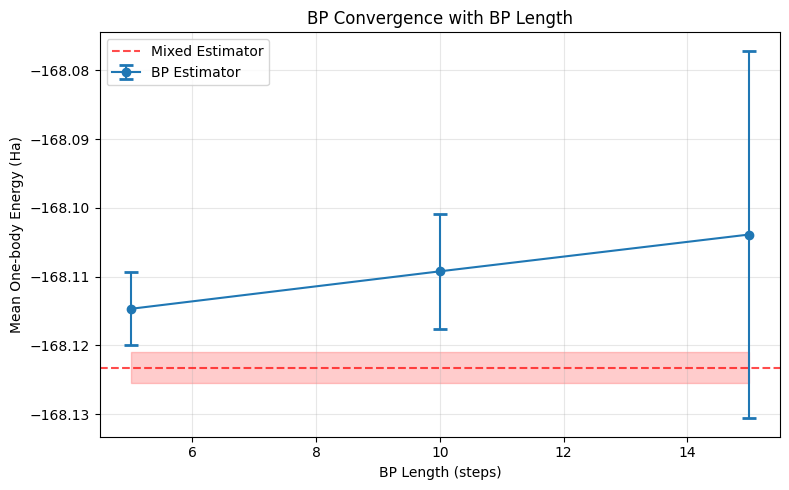

In [17]:
import matplotlib.pyplot as plt
from stats.scalar_dat import analyze_scalar_data

E_mixed, dE_mixed = analyze_scalar_data(dict(
    fname = scratch_dir/"qmc.s000.scalar.dat",
    series_column = "time",
    column = "OneBodyEnergyEstim__nume_real",
    nequil = 10
))

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

# plot reference value from mixed
ax.fill_between([min(bp_lengths), max(bp_lengths)],
                 E_mixed - dE_mixed, E_mixed + dE_mixed,
                 alpha=0.2, color='red')
ax.axhline(y=E_mixed, color='red', linestyle='--', alpha=0.7, label=f'Mixed Estimator')

# Plot convergence
ax.errorbar(bp_lengths, bp_energy, yerr=bp_energy_err, marker='o', capsize=5, capthick=2, label='BP Estimator')

ax.set_xlabel('BP Length (steps)')
ax.set_ylabel('Mean One-body Energy (Ha)')
ax.set_title('BP Convergence with BP Length')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Key Takeaways from Back-Propagation Analysis
---

**When to Use BP vs Mixed Estimators:**

1. **Mixed Estimators**: Use for observables that commute with the Hamiltonian (like energy). They are computationally cheaper and provide unbiased estimates.

2. **Back-Propagation**: Required for observables that do not commute with the Hamiltonian (like the one-body reduced density matrix). BP provides pure estimators that are unbiased.

**Important BP Configuration Points:**

- **Equilibration**: Always include an equilibration phase (`equil_multiplier`) to allow AFQMC to reach equilibrium before BP measurements begin.

- **Multiple BP Lengths**: Use multiple BP lengths to check convergence. Longer BP lengths generally provide more accurate results but are more expensive. However, BP is unstable for long back propagation times. This is reflected in the large stochastic uncertainty for large BP length.

- **Computational Cost**: BP calculations are significantly more expensive than mixed estimators due to the additional back-propagation steps.

**Convergence Analysis:**

The plots above show how the BP estimator converges with increasing BP length. For observables that don't commute with the Hamiltonian, you should see:
- Different results between mixed and BP estimators (showing the bias in mixed estimators)
- Dependence of BP esitmators on back-propagation length. It is important to note that BP does not necessarily converge and is unstable for large total imaginary time.

This demonstrates why BP is essential for computing unbiased estimates of observables like charge densities, spin densities, and other quantities derived from the one-body reduced density matrix.

&nbsp;

&nbsp;

## Summary
---

<font size="4">
In this tutorial, you were acquainted with how to compute general observables with SAFIRE.
</font>

&nbsp;

## What you learned
---

<font size="4">

1. What a mixed estimator is and when to use one to compute an observable
2. What a back-propagated estimator is and when to use one to compute an observable
3. How to compute observables in post-processing with afqmctools
</font>

&nbsp;